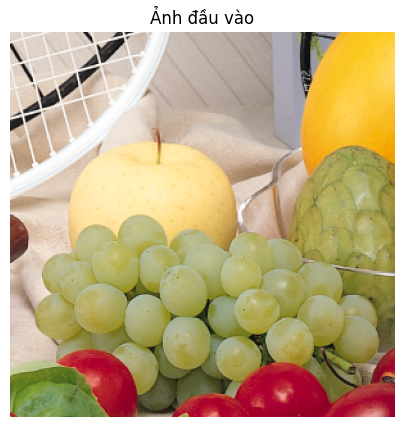

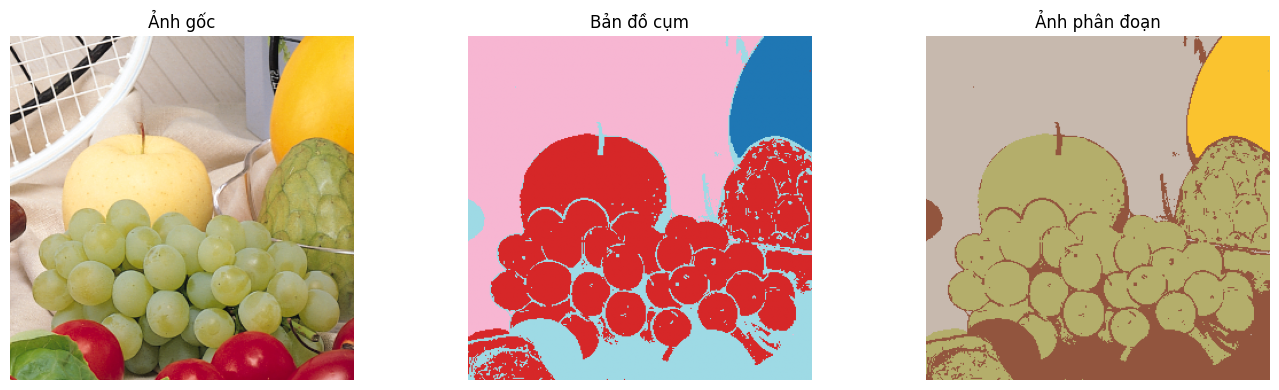

Kích thước ảnh: (300, 300, 3)
Số điểm ảnh: 90000
Kích thước ma trận đặc trưng: (90000, 6)
Số nhãn cụm khác nhau: 4
Các nhãn cụm: [0 1 2 3]
Kích thước bản đồ cụm: (300, 300)
Kích thước ảnh phân đoạn: (300, 300, 3)
Kiểm tra hoàn tất: chương trình chạy đúng.


In [ ]:
# ============================================================
# GIÁO TRÌNH: THỊ GIÁC MÁY: TỪ XỬ LÝ ẢNH ĐẾN HỌC SÂU
# BÀI CODE MINH HỌA: PHÂN ĐOẠN ẢNH DỰA TRÊN MÀU, TEXTURE VÀ VỊ TRÍ
# Chương/Mục liên quan: Chương 6 - Phân đoạn ảnh và gom cụm đặc trưng
# Thuật toán chính: Gaussian Mixture Model và Expectation-Maximization
# ============================================================

# ============================================================
# MÔ TẢ
# ============================================================

# Mục đích:
# - Minh họa bài toán phân đoạn ảnh bằng cách gom cụm các điểm ảnh.
# - Mỗi điểm ảnh được biểu diễn bởi vector đặc trưng gồm màu, texture và vị trí.
# - Thuật toán GMM + EM được dùng để chia các điểm ảnh thành các vùng tương đối đồng nhất.

# Sau khi chạy code, người học cần:
# 1. Quan sát được ảnh gốc, bản đồ cụm và ảnh phân đoạn.
# 2. Hiểu rằng phân đoạn ảnh có thể được xem như bài toán gom cụm trong không gian đặc trưng.
# 3. Nhận biết ảnh hưởng của số cụm n_segments đến kết quả phân đoạn.

# Input:
# - Dữ liệu đầu vào: ảnh fruits.png từ GitHub
# - Kiểu dữ liệu: ảnh màu RGB
# - Tiền xử lý: resize ảnh nếu kích thước lớn hơn max_size

# Output:
# - Ảnh gốc
# - Bản đồ cụm
# - Ảnh phân đoạn theo màu trung bình của từng cụm
# - Một số kiểm tra để chứng minh chương trình chạy đúng

# Lưu ý
# Đoạn code này được xây dựng với sự hỗ trợ của công cụ AI.
# Giảng viên đã đọc, kiểm tra và hiệu chỉnh nhằm bảo đảm tính chính xác,
# tính sư phạm và sự phù hợp với nội dung lý thuyết trong giáo trình.

# Người học không chỉ chạy code để xem kết quả, mà cần hiểu:
# - Code đang minh họa nội dung lý thuyết nào;
# - Các bước xử lý tương ứng với công thức hoặc thuật toán nào;
# - Kết quả đầu ra có hợp lý hay không;
# - Khi thay đổi tham số, kết quả thay đổi như thế nào.

# ============================================================
# 1. CÀI ĐẶT VÀ IMPORT THƯ VIỆN
# ============================================================

import numpy as np
import cv2
import matplotlib.pyplot as plt
import requests
from PIL import Image
from io import BytesIO
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

# ============================================================
# 2. TẢI DỮ LIỆU ĐẦU VÀO
# ============================================================

def load_image_from_url(url, max_size=300):
    response = requests.get(url)
    image = Image.open(BytesIO(response.content)).convert("RGB")
    image = np.array(image)

    h, w = image.shape[:2]
    scale = max_size / max(h, w)

    if scale < 1:
        image = cv2.resize(image, (int(w * scale), int(h * scale)))

    return image


url = "https://github.com/lthavnu/cv-book/raw/main/images/fruits.png"

I = load_image_from_url(url, max_size=300)

# ============================================================
# 3. HIỂN THỊ ẢNH ĐẦU VÀO
# ============================================================

plt.figure(figsize=(5, 5))
plt.imshow(I)
plt.axis("off")
plt.title("Ảnh đầu vào")
plt.show()

# ============================================================
# 4. XỬ LÝ CHÍNH
# ============================================================

def extract_features(image):
    h, w = image.shape[:2]

    # Công thức minh họa:
    # f(x, y) = [L*, a*, b*, texture, x, y]

    # Thành phần [L*, a*, b*]: đặc trưng màu trong không gian Lab
    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB).astype(np.float32)

    # Thành phần texture: độ lớn gradient tại mỗi điểm ảnh
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY).astype(np.float32)

    # Hai dòng dưới tương ứng với tính đạo hàm ảnh theo hai hướng x và y
    grad_x = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
    grad_y = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)

    # Dòng dưới tương ứng với công thức độ lớn gradient:
    # |grad I| = sqrt(Ix^2 + Iy^2)
    grad_mag = cv2.magnitude(grad_x, grad_y)

    # Thành phần vị trí: tọa độ x, y được chuẩn hóa về [0, 1]
    xs, ys = np.meshgrid(np.arange(w), np.arange(h))
    xs = xs.astype(np.float32) / w
    ys = ys.astype(np.float32) / h

    # Ghép các thành phần thành vector đặc trưng cho từng điểm ảnh
    features = np.dstack([
        lab[:, :, 0],
        lab[:, :, 1],
        lab[:, :, 2],
        grad_mag,
        xs,
        ys
    ])

    features_2d = features.reshape(-1, features.shape[-1])

    return features_2d, h, w


def cluster_features_gmm(features, n_segments=5, random_state=0):
    scaler = StandardScaler()

    # Chuẩn hóa đặc trưng trước khi gom cụm
    features_scaled = scaler.fit_transform(features)

    # Dòng dưới khởi tạo mô hình GMM với n_segments thành phần Gaussian
    gmm = GaussianMixture(
        n_components=n_segments,
        covariance_type="full",
        random_state=random_state,
        max_iter=100
    )

    # Dòng dưới thực hiện học GMM bằng EM và gán nhãn cụm cho từng điểm ảnh
    labels = gmm.fit_predict(features_scaled)

    return labels, gmm, scaler


def create_segmentation_result(image, labels, h, w):
    label_map = labels.reshape(h, w)

    segmented_image = np.zeros_like(image)

    # Với mỗi cụm, thay màu các điểm ảnh trong cụm bằng màu trung bình của cụm đó
    for k in np.unique(labels):
        mask = label_map == k
        mean_color = image[mask].mean(axis=0)
        segmented_image[mask] = mean_color

    return label_map, segmented_image.astype(np.uint8)


features, h, w = extract_features(I)

labels, gmm, scaler = cluster_features_gmm(
    features,
    n_segments=4,
    random_state=42
)

label_map, segmented_image = create_segmentation_result(
    I,
    labels,
    h,
    w
)

# ============================================================
# 5. HIỂN THỊ KẾT QUẢ
# ============================================================

def show_results(image, label_map, segmented_image):
    plt.figure(figsize=(14, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(image)
    plt.axis("off")
    plt.title("Ảnh gốc")

    plt.subplot(1, 3, 2)
    plt.imshow(label_map, cmap="tab20")
    plt.axis("off")
    plt.title("Bản đồ cụm")

    plt.subplot(1, 3, 3)
    plt.imshow(segmented_image)
    plt.axis("off")
    plt.title("Ảnh phân đoạn")

    plt.tight_layout()
    plt.show()


show_results(I, label_map, segmented_image)

# ============================================================
# 6. KIỂM TRA KẾT QUẢ
# ============================================================

print("Kích thước ảnh:", I.shape)
print("Số điểm ảnh:", h * w)
print("Kích thước ma trận đặc trưng:", features.shape)
print("Số nhãn cụm khác nhau:", len(np.unique(labels)))
print("Các nhãn cụm:", np.unique(labels))
print("Kích thước bản đồ cụm:", label_map.shape)
print("Kích thước ảnh phân đoạn:", segmented_image.shape)

assert features.shape[0] == h * w
assert label_map.shape == (h, w)
assert segmented_image.shape == I.shape
assert len(np.unique(labels)) == 4

print("Kiểm tra hoàn tất: chương trình chạy đúng.")

# ============================================================
# 7. GỢI Ý THỬ NGHIỆM CHO NGƯỜI HỌC
# ============================================================

# 1. Thay n_segments = 3, 5, 6 để quan sát số vùng phân đoạn thay đổi như thế nào.
# 2. Thay max_size = 200 hoặc 400 để quan sát ảnh hưởng của kích thước ảnh đến tốc độ chạy.
# 3. Thay random_state = 0, 1, 42 để quan sát ảnh hưởng của khởi tạo GMM đến kết quả gom cụm.